# Home Credit Default Risk: Application EDA

This notebook examines the primary application tables and answers eight initial EDA questions. Supporting credit-history tables require separate relational EDA and applicant-level aggregation.

**Assumption:** question 6 originally mentioned `SalePrice`, which belongs to a house-price problem. Here it is interpreted as correlation with `TARGET`.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 150)
pd.set_option("display.max_columns", 150)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw" / "application_train.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train = pd.read_csv(DATA_DIR / "application_train.csv")
test = pd.read_csv(DATA_DIR / "application_test.csv")
print(f"Train: {train.shape}; test: {test.shape}")

Train: (307511, 122); test: (48744, 121)


## 1. What is the target distribution?

`TARGET = 1` denotes payment difficulties. The class balance determines whether accuracy is meaningful and how validation should be stratified.

,count,percent
TARGET,,
0,282686,91.927118
1,24825,8.072882


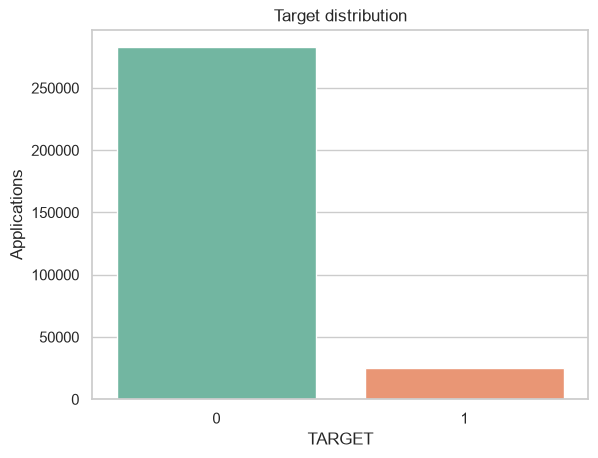

Positive-class rate: 8.07%
Finding: the target is imbalanced; use stratified validation and ranking metrics rather than accuracy.


In [2]:
target_summary = pd.DataFrame({
    "count": train["TARGET"].value_counts().sort_index(),
    "percent": train["TARGET"].value_counts(normalize=True).sort_index().mul(100),
})
display(target_summary)

ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette="Set2", legend=False)
ax.set(title="Target distribution", ylabel="Applications")
plt.show()

print(f"Positive-class rate: {train['TARGET'].mean():.2%}")
print("Finding: the target is imbalanced; use stratified validation and ranking metrics rather than accuracy.")

## 2. Which features have missing values?

,train_missing,train_pct,test_missing,test_pct
COMMONAREA_MODE,214865,69.872297,33495.0,68.716150
COMMONAREA_MEDI,214865,69.872297,33495.0,68.716150
COMMONAREA_AVG,214865,69.872297,33495.0,68.716150
NONLIVINGAPARTMENTS_MODE,213514,69.432963,33347.0,68.412523
NONLIVINGAPARTMENTS_MEDI,213514,69.432963,33347.0,68.412523
NONLIVINGAPARTMENTS_AVG,213514,69.432963,33347.0,68.412523
FONDKAPREMONT_MODE,210295,68.386172,32797.0,67.284179
LIVINGAPARTMENTS_MODE,210199,68.354953,32780.0,67.249302
LIVINGAPARTMENTS_MEDI,210199,68.354953,32780.0,67.249302
LIVINGAPARTMENTS_AVG,210199,68.354953,32780.0,67.249302


67 of 120 model features have missing training values.


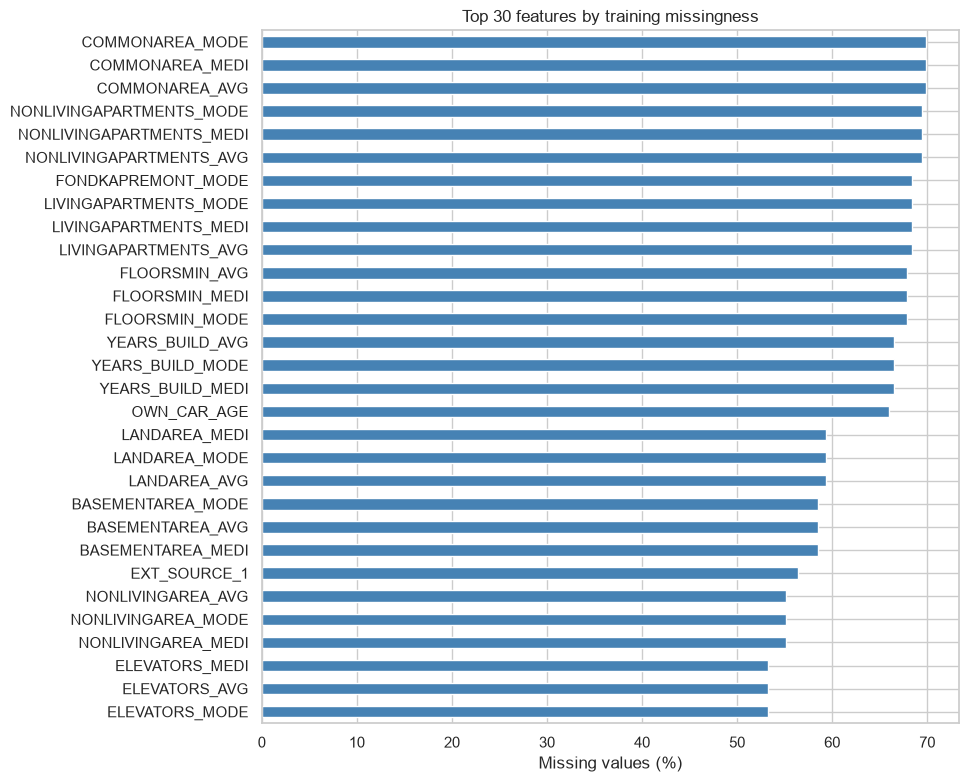

In [3]:
missing = pd.DataFrame({
    "train_missing": train.isna().sum(),
    "train_pct": train.isna().mean().mul(100),
    "test_missing": test.isna().sum(),
    "test_pct": test.isna().mean().mul(100),
}).sort_values("train_pct", ascending=False)
missing_features = missing[missing["train_missing"] > 0]
display(missing_features)
print(f"{len(missing_features)} of {train.shape[1] - 2} model features have missing training values.")

top_missing = missing_features.head(30).sort_values("train_pct")
top_missing["train_pct"].plot.barh(figsize=(9, 9), color="steelblue")
plt.title("Top 30 features by training missingness")
plt.xlabel("Missing values (%)")
plt.show()

## 3. Which missing values mean “None” rather than missing data?

The dataset documentation does not define a universal `None` category. Structural missingness should be inferred only where another field makes the condition explicit. `OWN_CAR_AGE` is the clearest example: a customer without a car has no applicable car age. Housing and occupation fields may be unavailable or inapplicable, but should not be recoded as `None` without stronger evidence.

The data also contain non-null sentinel values such as `XNA`, `Unknown`, and `DAYS_EMPLOYED = 365243`. These are not ordinary measured values and need explicit handling.

In [4]:
car_missing = pd.crosstab(
    train["FLAG_OWN_CAR"],
    train["OWN_CAR_AGE"].isna(),
    normalize="index",
).rename(columns={False: "car_age_present", True: "car_age_missing"})
display(car_missing)

sentinel_rows = []
for col in train.select_dtypes(include=["object", "string"]).columns:
    counts = train[col].value_counts(dropna=False)
    for value in ["XNA", "Unknown"]:
        if value in counts.index:
            sentinel_rows.append((col, value, int(counts[value])))
sentinels = pd.DataFrame(sentinel_rows, columns=["feature", "sentinel", "count"])
display(sentinels)
print("DAYS_EMPLOYED sentinel count:", int((train["DAYS_EMPLOYED"] == 365243).sum()))
print("Finding: recode structural/sentinel cases explicitly; do not blindly treat every NaN as the same phenomenon.")

OWN_CAR_AGE,car_age_present,car_age_missing
FLAG_OWN_CAR,,
N,0.000000,1.000000
Y,0.999952,0.000048


,feature,sentinel,count
0,CODE_GENDER,XNA,4
1,NAME_FAMILY_STATUS,Unknown,2
2,ORGANIZATION_TYPE,XNA,55374


DAYS_EMPLOYED sentinel count: 55374
Finding: recode structural/sentinel cases explicitly; do not blindly treat every NaN as the same phenomenon.


## 4. Which numerical features are skewed?

Identifier, target, and binary indicator columns are excluded. Skewness is calculated on non-null training values.

,skewness,abs_skewness
AMT_INCOME_TOTAL,391.559654,391.559654
AMT_REQ_CREDIT_BUREAU_QRT,134.365776,134.365776
NONLIVINGAPARTMENTS_MODE,16.251819,16.251819
NONLIVINGAPARTMENTS_MEDI,15.671995,15.671995
YEARS_BEGINEXPLUATATION_MEDI,-15.573124,15.573124
NONLIVINGAPARTMENTS_AVG,15.541185,15.541185
YEARS_BEGINEXPLUATATION_AVG,-15.515264,15.515264
YEARS_BEGINEXPLUATATION_MODE,-14.755318,14.755318
OBS_30_CNT_SOCIAL_CIRCLE,12.139598,12.139598
OBS_60_CNT_SOCIAL_CIRCLE,12.070829,12.070829


Features with |skew| > 1: 51 of 65


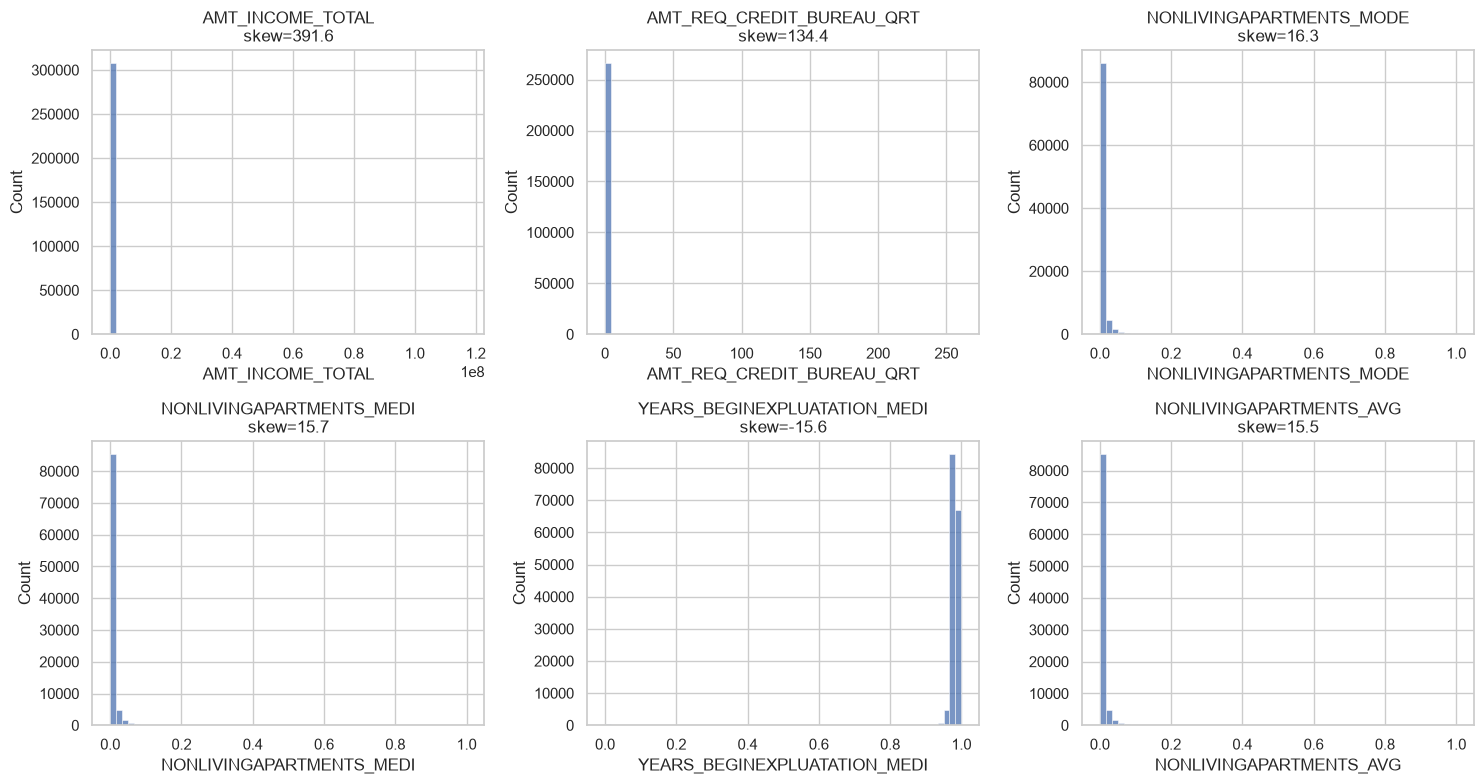

Finding: many amount, count, and rare-event features are strongly right-skewed; ratios, clipping, or log1p transforms may help linear models.


In [5]:
numeric_cols = train.select_dtypes(include=np.number).columns.difference(["SK_ID_CURR", "TARGET"])
continuous_cols = [c for c in numeric_cols if train[c].nunique(dropna=True) > 10]
skewness = train[continuous_cols].skew().sort_values(key=np.abs, ascending=False)
skew_table = skewness.rename("skewness").to_frame()
skew_table["abs_skewness"] = skew_table["skewness"].abs()
display(skew_table.head(30))
print(f"Features with |skew| > 1: {(skew_table['abs_skewness'] > 1).sum()} of {len(skew_table)}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for col, ax in zip(skew_table.head(6).index, axes.flat):
    sns.histplot(train[col].dropna(), bins=60, ax=ax)
    ax.set_title(f"{col}\nskew={skewness[col]:.1f}")
plt.tight_layout()
plt.show()
print("Finding: many amount, count, and rare-event features are strongly right-skewed; ratios, clipping, or log1p transforms may help linear models.")

## 5. Which categorical features have high cardinality?

,train_unique,test_unique
ORGANIZATION_TYPE,58,58
OCCUPATION_TYPE,19,19
NAME_TYPE_SUITE,8,8
NAME_INCOME_TYPE,8,7
WALLSMATERIAL_MODE,8,8
WEEKDAY_APPR_PROCESS_START,7,7
NAME_FAMILY_STATUS,6,5
NAME_HOUSING_TYPE,6,6
NAME_EDUCATION_TYPE,5,5
FONDKAPREMONT_MODE,5,5


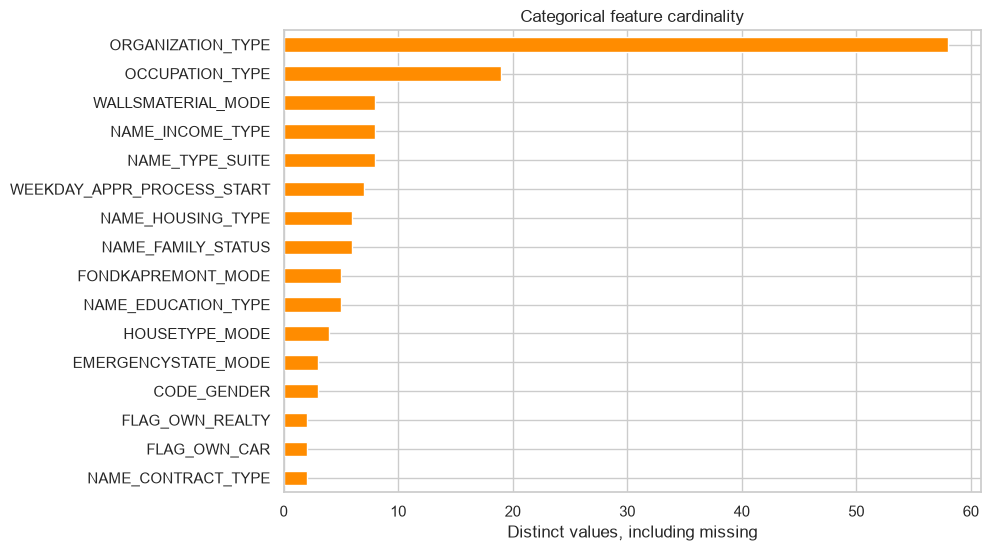

Finding: ORGANIZATION_TYPE and OCCUPATION_TYPE are the highest-cardinality application categories, but cardinality is still manageable for boosting or one-hot encoding.


In [6]:
categorical_cols = train.select_dtypes(include=["object", "string"]).columns.tolist()
cardinality = pd.DataFrame({
    "train_unique": train[categorical_cols].nunique(dropna=False),
    "test_unique": test[categorical_cols].nunique(dropna=False),
}).sort_values("train_unique", ascending=False)
display(cardinality)

cardinality.sort_values("train_unique")["train_unique"].plot.barh(figsize=(9, 6), color="darkorange")
plt.title("Categorical feature cardinality")
plt.xlabel("Distinct values, including missing")
plt.show()
print("Finding: ORGANIZATION_TYPE and OCCUPATION_TYPE are the highest-cardinality application categories, but cardinality is still manageable for boosting or one-hot encoding.")

## 6. Which features are strongly correlated with `TARGET`?

Pearson correlation captures only linear, univariate relationships. It is useful for screening but does not measure nonlinear effects or interactions.

,correlation_with_TARGET
EXT_SOURCE_3,-0.178919
EXT_SOURCE_2,-0.160472
EXT_SOURCE_1,-0.155317
DAYS_BIRTH,0.078239
REGION_RATING_CLIENT_W_CITY,0.060893
REGION_RATING_CLIENT,0.058899
DAYS_LAST_PHONE_CHANGE,0.055218
DAYS_ID_PUBLISH,0.051457
REG_CITY_NOT_WORK_CITY,0.050994
FLAG_EMP_PHONE,0.045982


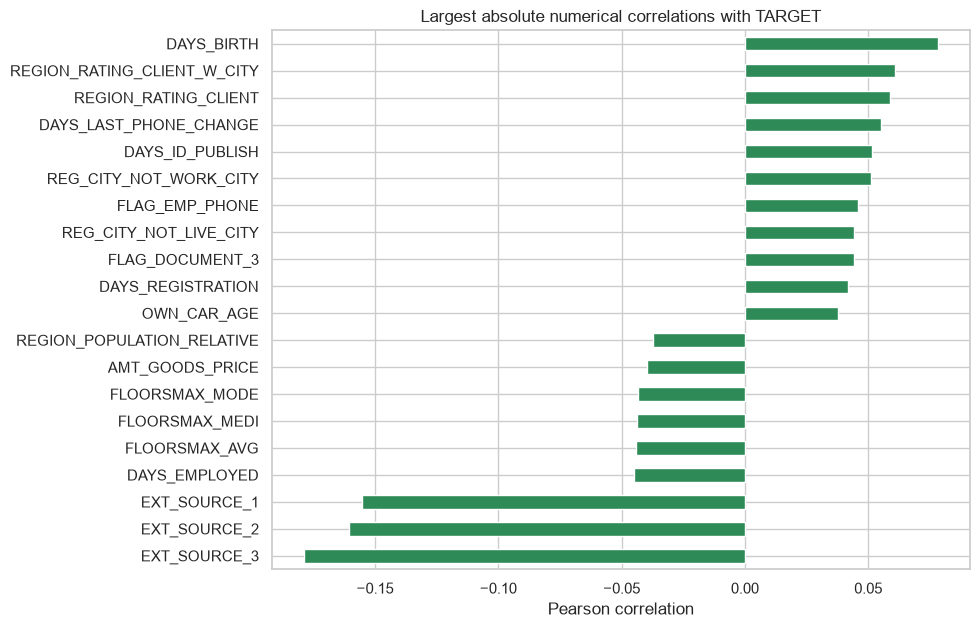

Finding: the three EXT_SOURCE scores dominate simple numerical correlations; no single raw feature has an extremely strong linear relationship with TARGET.


In [7]:
target_corr = (
    train.select_dtypes(include=np.number)
    .corr()["TARGET"]
    .drop(["TARGET", "SK_ID_CURR"])
    .sort_values(key=np.abs, ascending=False)
)
display(target_corr.head(25).rename("correlation_with_TARGET").to_frame())

target_corr.head(20).sort_values().plot.barh(figsize=(9, 7), color="seagreen")
plt.title("Largest absolute numerical correlations with TARGET")
plt.xlabel("Pearson correlation")
plt.show()
print("Finding: the three EXT_SOURCE scores dominate simple numerical correlations; no single raw feature has an extremely strong linear relationship with TARGET.")

## 7. Are there obvious outliers?

The IQR rule is a screening device, not an automatic deletion rule. Financial variables naturally have long tails. We also inspect known domain anomalies.

,min,p99,max,iqr_outliers,iqr_outlier_pct
feature,,,,,
AMT_INCOME_TOTAL,25650.0,472500.0,117000000.0,14035,4.564064
AMT_CREDIT,45000.0,1854000.0,4050000.0,6562,2.133907
AMT_ANNUITY,1615.5,70006.5,258025.5,7504,2.440333
AMT_GOODS_PRICE,40500.0,1800000.0,4050000.0,14728,4.793756
CNT_CHILDREN,0.0,3.0,19.0,4272,1.389219
CNT_FAM_MEMBERS,1.0,5.0,20.0,4007,1.303051
OWN_CAR_AGE,0.0,64.0,91.0,4932,4.715917


DAYS_EMPLOYED = 365243: 55374
CODE_GENDER = XNA: 4


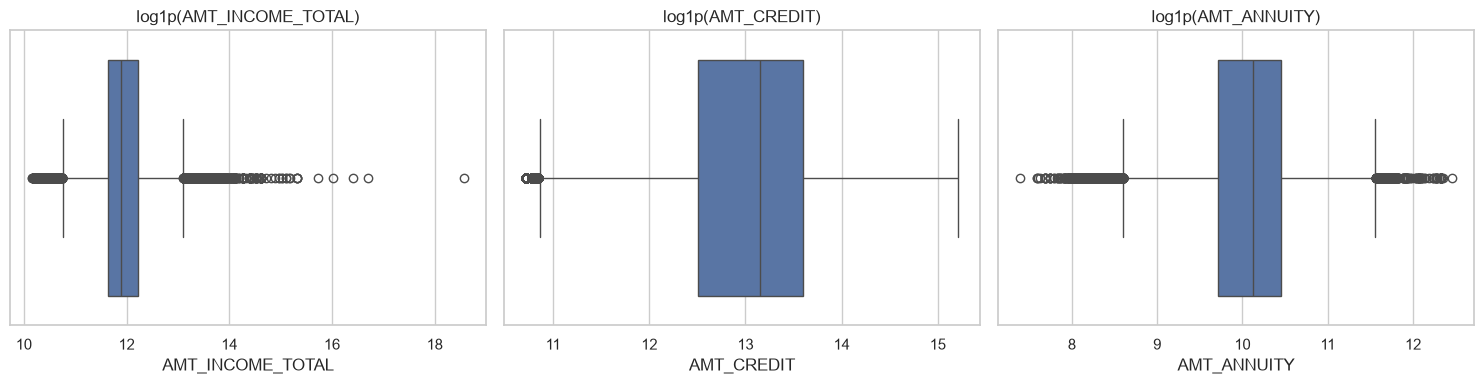

Finding: monetary variables have genuine long tails, while DAYS_EMPLOYED=365243 is a clear sentinel. Investigate extreme values before clipping or removal.


In [8]:
outlier_cols = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS", "OWN_CAR_AGE",
]
outlier_rows = []
for col in outlier_cols:
    s = train[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_rows.append({
        "feature": col, "min": s.min(), "p99": s.quantile(.99), "max": s.max(),
        "iqr_outliers": int(((s < low) | (s > high)).sum()),
        "iqr_outlier_pct": ((s < low) | (s > high)).mean() * 100,
    })
display(pd.DataFrame(outlier_rows).set_index("feature"))

print("DAYS_EMPLOYED = 365243:", int((train["DAYS_EMPLOYED"] == 365243).sum()))
print("CODE_GENDER = XNA:", int((train["CODE_GENDER"] == "XNA").sum()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for col, ax in zip(["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"], axes):
    sns.boxplot(x=np.log1p(train[col].dropna()), ax=ax)
    ax.set_title(f"log1p({col})")
plt.tight_layout()
plt.show()
print("Finding: monetary variables have genuine long tails, while DAYS_EMPLOYED=365243 is a clear sentinel. Investigate extreme values before clipping or removal.")

## 8. Are train and test distributions similar?

We compare missingness, numerical Population Stability Index (PSI), and categorical total-variation distance. These are screening statistics: large values identify features requiring closer inspection.

,absolute_missing_rate_difference
EXT_SOURCE_1,0.142590
EXT_SOURCE_3,0.020426
ENTRANCES_AVG,0.019756
ENTRANCES_MODE,0.019756
ENTRANCES_MEDI,0.019756
FLOORSMAX_MODE,0.019170
FLOORSMAX_AVG,0.019170
FLOORSMAX_MEDI,0.019170
YEARS_BEGINEXPLUATATION_MODE,0.018911
YEARS_BEGINEXPLUATATION_MEDI,0.018911


,PSI
AMT_REQ_CREDIT_BUREAU_MON,0.159876
AMT_GOODS_PRICE,0.083040
AMT_CREDIT,0.069183
DAYS_ID_PUBLISH,0.067059
DAYS_LAST_PHONE_CHANGE,0.051822
AMT_ANNUITY,0.032594
AMT_INCOME_TOTAL,0.020051
OWN_CAR_AGE,0.016712
EXT_SOURCE_2,0.009977
AMT_REQ_CREDIT_BUREAU_YEAR,0.007332


,total_variation
NAME_CONTRACT_TYPE,0.086207
WEEKDAY_APPR_PROCESS_START,0.045092
ORGANIZATION_TYPE,0.026058
NAME_FAMILY_STATUS,0.023516
NAME_TYPE_SUITE,0.021439
WALLSMATERIAL_MODE,0.020401
EMERGENCYSTATE_MODE,0.018625
HOUSETYPE_MODE,0.017209
NAME_EDUCATION_TYPE,0.015578
OCCUPATION_TYPE,0.014556


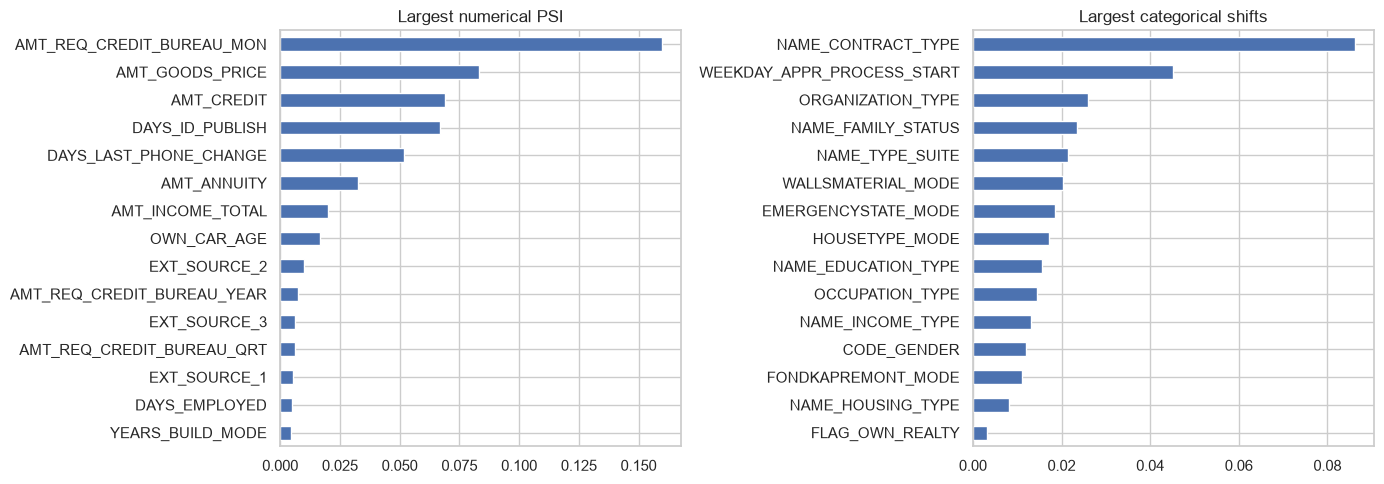

Finding: review the highest-shift features, but do not drop them solely from a univariate statistic. Cross-validation remains the main estimate of generalization.


In [9]:
missing_shift = (train.drop(columns="TARGET").isna().mean() - test.isna().mean()).abs().sort_values(ascending=False)
display(missing_shift.head(20).rename("absolute_missing_rate_difference").to_frame())

def numeric_psi(train_s, test_s, bins=10):
    train_s, test_s = train_s.dropna(), test_s.dropna()
    if train_s.nunique() < 2 or test_s.empty:
        return np.nan
    edges = np.unique(train_s.quantile(np.linspace(0, 1, bins + 1)).values)
    if len(edges) < 3:
        return np.nan
    edges[0], edges[-1] = -np.inf, np.inf
    train_p = pd.cut(train_s, edges).value_counts(normalize=True, sort=False).clip(1e-6)
    test_p = pd.cut(test_s, edges).value_counts(normalize=True, sort=False).clip(1e-6)
    return float(((test_p - train_p) * np.log(test_p / train_p)).sum())

psi = pd.Series({c: numeric_psi(train[c], test[c]) for c in numeric_cols}, name="PSI").sort_values(ascending=False)
display(psi.head(20).to_frame())

def categorical_tv(train_s, test_s):
    a = train_s.fillna("<MISSING>").value_counts(normalize=True)
    b = test_s.fillna("<MISSING>").value_counts(normalize=True)
    categories = a.index.union(b.index)
    return float(0.5 * (a.reindex(categories, fill_value=0) - b.reindex(categories, fill_value=0)).abs().sum())

cat_shift = pd.Series({c: categorical_tv(train[c], test[c]) for c in categorical_cols}, name="total_variation").sort_values(ascending=False)
display(cat_shift.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
psi.head(15).sort_values().plot.barh(ax=axes[0], title="Largest numerical PSI")
cat_shift.head(15).sort_values().plot.barh(ax=axes[1], title="Largest categorical shifts")
plt.tight_layout()
plt.show()
print("Finding: review the highest-shift features, but do not drop them solely from a univariate statistic. Cross-validation remains the main estimate of generalization.")

## Initial conclusions

1. The target is imbalanced, making stratified ROC-AUC validation essential.
2. Missingness is extensive and sometimes structural; missing indicators may be predictive.
3. External risk scores are important raw predictors, but no single feature solves the task.
4. Numerical variables include skewed long tails and explicit sentinel values.
5. Application categorical cardinality is manageable for gradient boosting.
6. Train/test shift should be monitored feature by feature and through cross-validation.
7. The next EDA stage should aggregate the six historical tables by `SK_ID_CURR` and examine delinquency, payment, recency, and credit-count features.